In [2]:
import numpy as np
from scipy.optimize import fsolve, root

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

### Importing the datasets

In [3]:
inputs = xr.open_dataset("../model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

outputs = xr.open_dataset("../model_output_dataset.nc")

q_used = np.array([0.13,0.22,0.17,0.05,0.21,0.07,0.05,0.1,0.1])*1e6 #m^3/s

### Defining the parameters

In [4]:
# Define reference properties and parameters 

#EOS
T_star = 0 # °C  (PICO)
S_star = 34 # PSU   (PICO)
rho_star = 1033 # kg/m^3   (PICO)
alpha = 7.5e-5 # /°C   (PICO)
beta = 7.7e-4 # /PSU (PICO)

def EOS(T,S):
    return rho_star*(1-alpha*(T-T_star)+beta*(S-S_star))
    
#Liquidus
la = -0.0572 # °C/PSU   (PICO)
lb = 0.0788 # °C   (PICO)
lc = 7.59e-4 # °C/m   (PICO->Burgard)

def liquidus(S,h):
    return la*S+lb-lc*h

#Water properties
L = 3.34e5 # J/kg   (PICO)
c_star = 3974 # J/kg/°C   (PICO)
lambd = L/c_star # 84 K

#Ice properties
rho_i = 910 # kg/m^3   (PICO)
nu = rho_i/rho_star #0.88

#PICO parameters
# Reese 2018
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C2 = 4e6 #m^6/s/kg

### PICO solver cst q

In [5]:
def PICO_qcst(Td,Sd,nbox,q,gammaT,Ac,frac,depth):

    g1 = Ac*frac*gammaT # list of g1
    g2 = g1/nu/lambd
    s = Sd/nu/lambd

    # management of the 1st box
    T_st_0 = la*Sd+lb-lc*depth[0]-Td
    x0 = -g1[0]*T_st_0/(q+g1[0]-g2[0]*la*Sd)
    y0 = Sd*x0/nu/lambd
    T0 = Td-x0
    S0 = Sd-y0

    # management of the other boxes
    T = np.zeros(nbox)
    S = np.zeros(nbox)
    m = np.zeros(nbox)
    T[0] = T0
    S[0] = S0
    m[0] = -gammaT/nu/lambd*(la*S[0]+lb-lc*depth[0]-T[0])*3600*24*30 #m/30d
    for k in range(1,nbox):
        T_st = la*S[k-1]+lb-lc*depth[k]-T[k-1]
        x = -g1[k]*T_st/(q+g1[k]-g2[k]*la*S[k-1])
        y = S[k-1]*x/nu/lambd
        T[k] = T[k-1]-x
        S[k] = S[k-1]-y
        m[k] = -gammaT/nu/lambd*(la*S[k]+lb-lc*depth[k]-T[k])*3600*24*30 #m/30d
    
    return T,S,m

### Box model solver cst q

In [6]:
# compute AABW flux [m^3/s]
def compute_DSW(X, C2, T0, S0):
    return np.max(np.array([0,C2*(EOS(X[1],X[3])-EOS(T0,S0))]))

# compute water column stability [kg/m^3]
def compute_Sigma(X):
    return EOS(X[0],X[2])-EOS(X[1],X[3])

# Compute melt rate averaged over all the cavity boxes [m/30d]
def compute_m_avg(m,frac,nbox):
    return np.average(m, weights=frac[:nbox])

def BoxModel(X, nbox, q, gammaT, Ac, Omega, T0, S0, Ap, kappa, g, frac, depth, C2, T_surf, S_surf, AABW):
    
    #compute k 
    k = kappa/gammaT

    #compute phi
    phi = Ap/Ac

    #define variables
    Tp, Td, Sp, Sd = X

    # Cavity dynamics with PICO 
    Tc,Sc,m = PICO_qcst(Td,Sd, nbox, q, gammaT, Ac, frac, depth)

    chi = q/Ac/gammaT

    # Dense Shelf Water flux
    if AABW:
        if k>2: # Here we consider we are in the convective mode so we create AABW
            DSW = compute_DSW(X, C2, T0, S0)/Ac/gammaT
        else:
            DSW = 0
        
    # create an empty vector that will contains the dynamical system
    vect_out = np.zeros(len(X))

    if AABW:
        # polynya box equations
        vect_out[0] = chi*(Tc[-1]-Tp)-phi*k*(Tp-Td)+phi*g*(liquidus(Sp,0)-Tp) +DSW*(T_surf-Tp)
        vect_out[2] = chi*(Sc[-1]-Sp)-phi*k*(Sp-Sd)+phi*rho_i/rho_star*Sp/gammaT*Omega +DSW*(S_surf-Sp)
    
        # deep box equations
        vect_out[1] = chi*(T0-Td)+phi*k*(Tp-Td) -DSW*(Td-Tp)
        vect_out[3] = chi*(S0-Sd)+phi*k*(Sp-Sd) -DSW*(Sd-Sp)

    else: #without AABW formation
        # polynya box equations
        vect_out[0] = chi*(Tc[-1]-Tp)-phi*k*(Tp-Td)+phi*g*(liquidus(Sp,0)-Tp)
        vect_out[2] = chi*(Sc[-1]-Sp)-phi*k*(Sp-Sd)+phi*rho_i/rho_star*Sp/gammaT*Omega
    
        # deep box equations
        vect_out[1] = chi*(T0-Td)+phi*k*(Tp-Td)
        vect_out[3] = chi*(S0-Sd)+phi*k*(Sp-Sd)

    return vect_out

### Plot Figure

Ross
Filchner-Ronne
Amery
Dotson
Pine Island
Riiser-Larsen
Roi Baudouin
Totten
Moscow Univ.


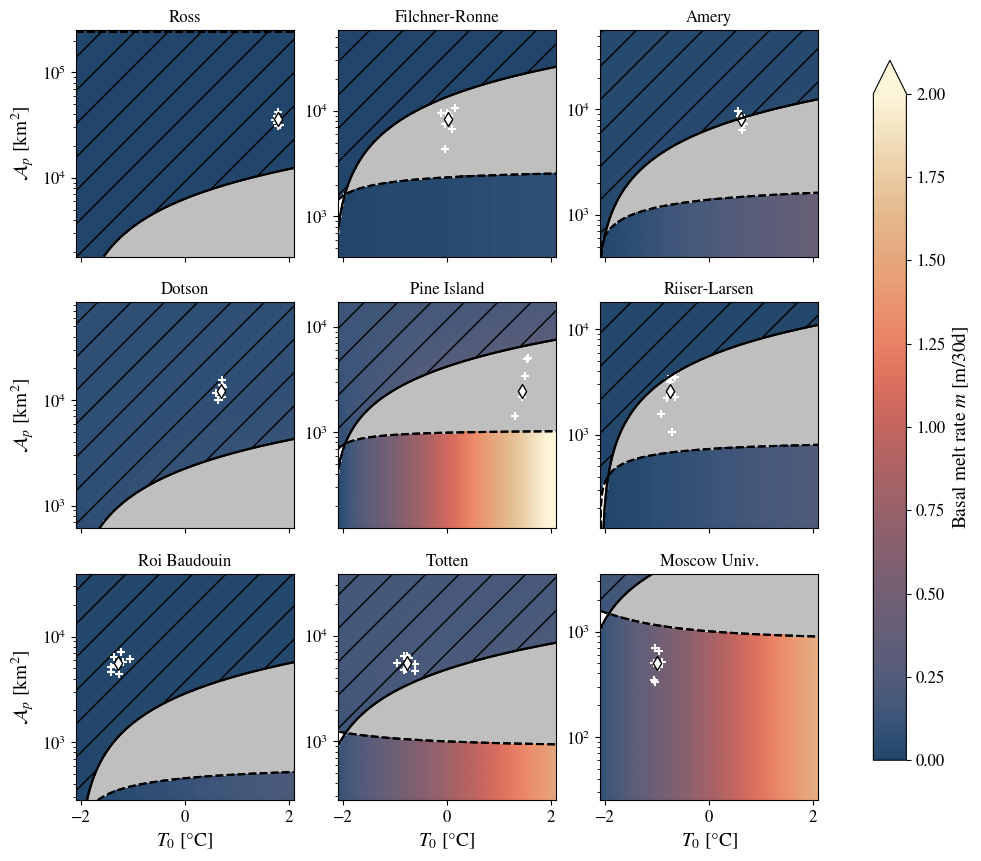

In [7]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this seed works well here


AABW = False #Include AABW parameterisation ?

fig, ax = plt.subplots(3,3,figsize=(11,10),sharex=True)

Npoint = 100

T0_list = np.linspace(-2.1,2.1,Npoint)

for k, index, name in zip(np.arange(9),index_isf,name_isf):
    print(name)

    Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)
    Ap_list = np.logspace(np.log10(Ap_ref/20),np.log10(Ap_ref*7),Npoint)
    
    
    i = k//3
    j = k%3


    stability_d = np.zeros((Npoint,Npoint))
    stability_c = np.zeros((Npoint,Npoint))

    melt_d = np.zeros((Npoint,Npoint))
    melt_c = np.zeros((Npoint,Npoint))

    sigma_d = np.zeros((Npoint,Npoint))
    sigma_c = np.zeros((Npoint,Npoint))
    
    nbox = int(inputs.Nbox.sel(Nisf=index).values)
    Ac = inputs.Ac.sel(Nisf=index).values #m^2

    Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 #m/s
    
    frac = inputs.frac.sel(Nisf=index).values
    depth = inputs.depth.sel(Nisf=index).values
    T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
    S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
    S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)

    q_ref = q_used[k]
    
    guess_conv_0 = np.array([0,0,35.5,35.5])
    guess_diff_0 = np.array([0,0,35.5,35.5])
    
    for n, T0 in enumerate(T0_list):

        guess_conv = guess_conv_0
        guess_diff = guess_diff_0
        
        for m, Ap in enumerate(Ap_list):
                
    
            X_d, info, ier, msg = fsolve(BoxModel, guess_diff, args = (nbox,q_ref,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True,)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1 or X_d[3]<30 or X_d[1]<30:
                    X_d, info, ier, msg = fsolve(BoxModel, np.random.normal(guess_diff,0.15), args = (nbox,q_ref,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, diff',m,n)
                        break
            if ier == 1:
                guess_diff = X_d
                if m==0:
                    guess_diff_0 = X_d 

            if ier==1:
                sigma_d[m,n] = compute_Sigma(X_d)
                stability_d[m,n] = compute_Sigma(X_d)<0
                if stability_d[m,n]:
                    T,S,melt = PICO_qcst(X_d[1],X_d[3], nbox, q_ref, gammaT, Ac, frac, depth)
                    melt_d[m,n] = compute_m_avg(melt,frac,nbox)
                    #melt_d[m,n] = melt[0] # only in first box
                else:
                    melt_d[m,n] = np.nan
            else:
                stability_d[m,n] = np.nan
                melt_d[m,n] = np.nan
                
            
            X_c, info, ier, msg = fsolve(BoxModel, guess_conv, args = (nbox,q_ref,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
            if ier != 1: #management of non convergence cases
                incr = 0
                while ier != 1:
                    X_c, info, ier, msg = fsolve(BoxModel, np.random.normal(guess_conv,0.15), args = (nbox,q_ref,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, AABW), full_output=True)
                    incr += 1
                    if incr == 200:
                        print('no conv, conv',m,n)
                        break
            if ier==1:
                guess_conv = X_c
                if m==0:
                    guess_conv_0 = X_c
            

            if ier==1:
                sigma_c[m,n] = compute_Sigma(X_c)
                stability_c[m,n] = compute_Sigma(X_c)>0
                if stability_c[m,n]:
                    T,S,melt = PICO_qcst(X_c[1],X_c[3], nbox, q_ref, gammaT, Ac, frac, depth)
                    melt_c[m,n] = compute_m_avg(melt,frac,nbox)
                    #melt_c[m,n] = melt[0]  # only in first box
                else:
                    melt_c[m,n] = np.nan
            else:
                stability_c[m,n] = np.nan
                melt_c[m,n] = np.nan

            
    # show monostable and bistable cases
    stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1

    # show unstable cases 
    stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_c,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    melt_diff = ax[i,j].pcolormesh(T0_list,Ap_list/1e6,melt_d,cmap=lipari_cut,vmin=0,vmax=2,shading='gouraud') # Ap in km²
    bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
    ax[i,j].pcolormesh(T0_list,Ap_list/1e6,bistable_zone,cmap='binary',vmin=0,vmax=1) # Ap in km²

    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
    ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')

    if np.max(sigma_d)>0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_d,colors='black',levels=0)
        ax[i,j].contourf(T0_list,Ap_list/1e6,np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)),sigma_d),hatches='/',levels=[0,500],alpha=0)
    if np.min(sigma_c)<0:
        ax[i,j].contour(T0_list,Ap_list/1e6,sigma_c,colors='black',levels=0,linestyles='dashed')
    
    ax[i,j].set_title(name)
    ax[i,j].set_yscale('log')
    ax[i,j].set_xlim((-2.1,2.1))
    ax[i,j].set_ylim((Ap_list.min()/1e6,Ap_list.max()/1e6))
    
    if j==0:
        ax[i,j].set_ylabel(r'$\mathcal{A}_p$'+' '+r'$\mathrm{[km^2]}$')
    if i==2:
        ax[i,j].set_xlabel(r'$T_0$'+' [°C]')

    T0_series = inputs.T0.sel(Nisf=index).values
    Ap_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values
    
    ax[i,j].scatter(T0_series,Ap_series/1e6,marker='+', c='white') # Ap in km²

    ax[i,j].scatter(np.mean(T0_series),np.mean(Ap_series)/1e6,facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1) #interannual mean

   
    
    #Ap_summer = 1/4*0.04/0.96*np.mean(Ap_series)*8
    #ax[i,j].scatter(np.mean(T0_series), Ap_summer/1e6,facecolors='white',edgecolors='black',linewidths=0.75,marker=r'$\mathrm{s}$',s=125) # Ap in km²
    
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(melt_diff,cax=cbar_ax, label = 'Basal melt rate '+r'$m$'+' [m/30d]', extend='max')
plt.savefig('Figures/Constant_q.png',dpi=300,format="png", bbox_inches = 'tight')
plt.show()